<a href="https://colab.research.google.com/github/OjashShakya/Ojash_Shakya_2408654_AI_Worksheets/blob/main/2408654_OjashShakya_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2: Vision Tasks

## Image Classification with Convolutional Neural Network - Scene Classification for Natural Environment Recognition

## Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Check GPU

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Import Libraries


In [ ]:
import os
import time
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from pathlib import Path
from collections import Counter, defaultdict

from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

These libraries help us:

1. read and organize data
2. build CNN models
3. train and evaluate models
4. visualize results clearly

# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.

##  Data Understanding, Analysis, Visualization and Cleaning

### Set Dataset path

In [ ]:
base_dir = Path("/content/drive/MyDrive/6th Sem/Artificial Intelligence and Machine Learning/Coursework/Scene Classification")
train_dir = base_dir / "train"
test_dir = base_dir / "test"

print("Train directory exists:", train_dir.exists())
print("Test directory exists:", test_dir.exists())
print("Train path:", train_dir)
print("Test path:", test_dir)

Train directory exists: True
Test directory exists: True
Train path: /content/drive/MyDrive/Scene Classification/train
Test path: /content/drive/MyDrive/Scene Classification/test


### Understand dataset structure

In [ ]:
train_counts = {}
test_counts = {}

for class_name in sorted(os.listdir(train_dir)):
    class_path = train_dir / class_name
    if class_path.is_dir():
        train_counts[class_name] = len(list(class_path.glob("*.jpg")))

for class_name in sorted(os.listdir(test_dir)):
    class_path = test_dir / class_name
    if class_path.is_dir():
        test_counts[class_name] = len(list(class_path.glob("*.jpg")))

print("Training class counts:")
print(train_counts)

print("\nTesting class counts:")
print(test_counts)

print("\nTotal train images:", sum(train_counts.values()))
print("Total test images:", sum(test_counts.values()))
print("Number of classes:", len(train_counts))

Training class counts:
{'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}

Testing class counts:
{'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}

Total train images: 14034
Total test images: 3000
Number of classes: 6


### Plot Class Distribution

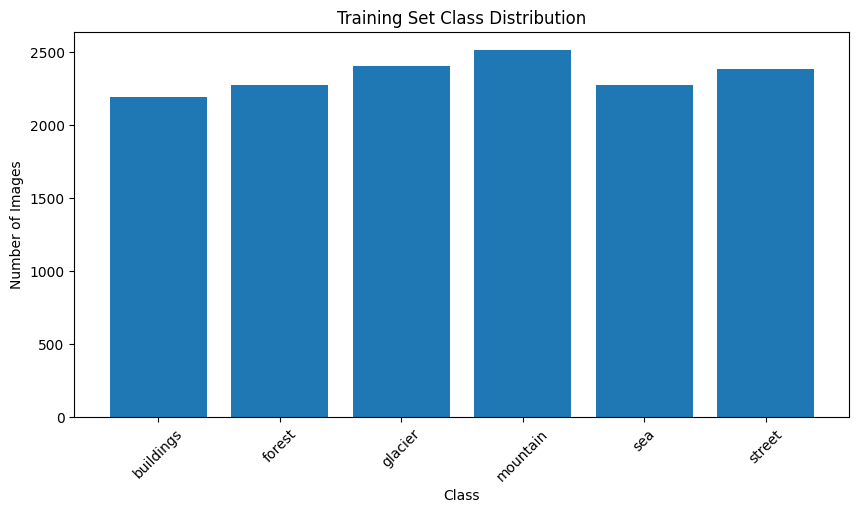

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

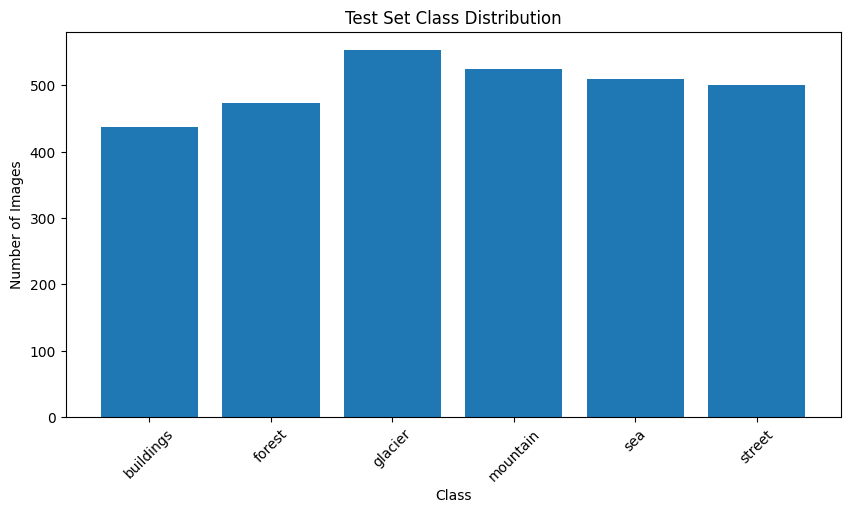

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(test_counts.keys(), test_counts.values())
plt.title("Test Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

### Showing sample image from each class

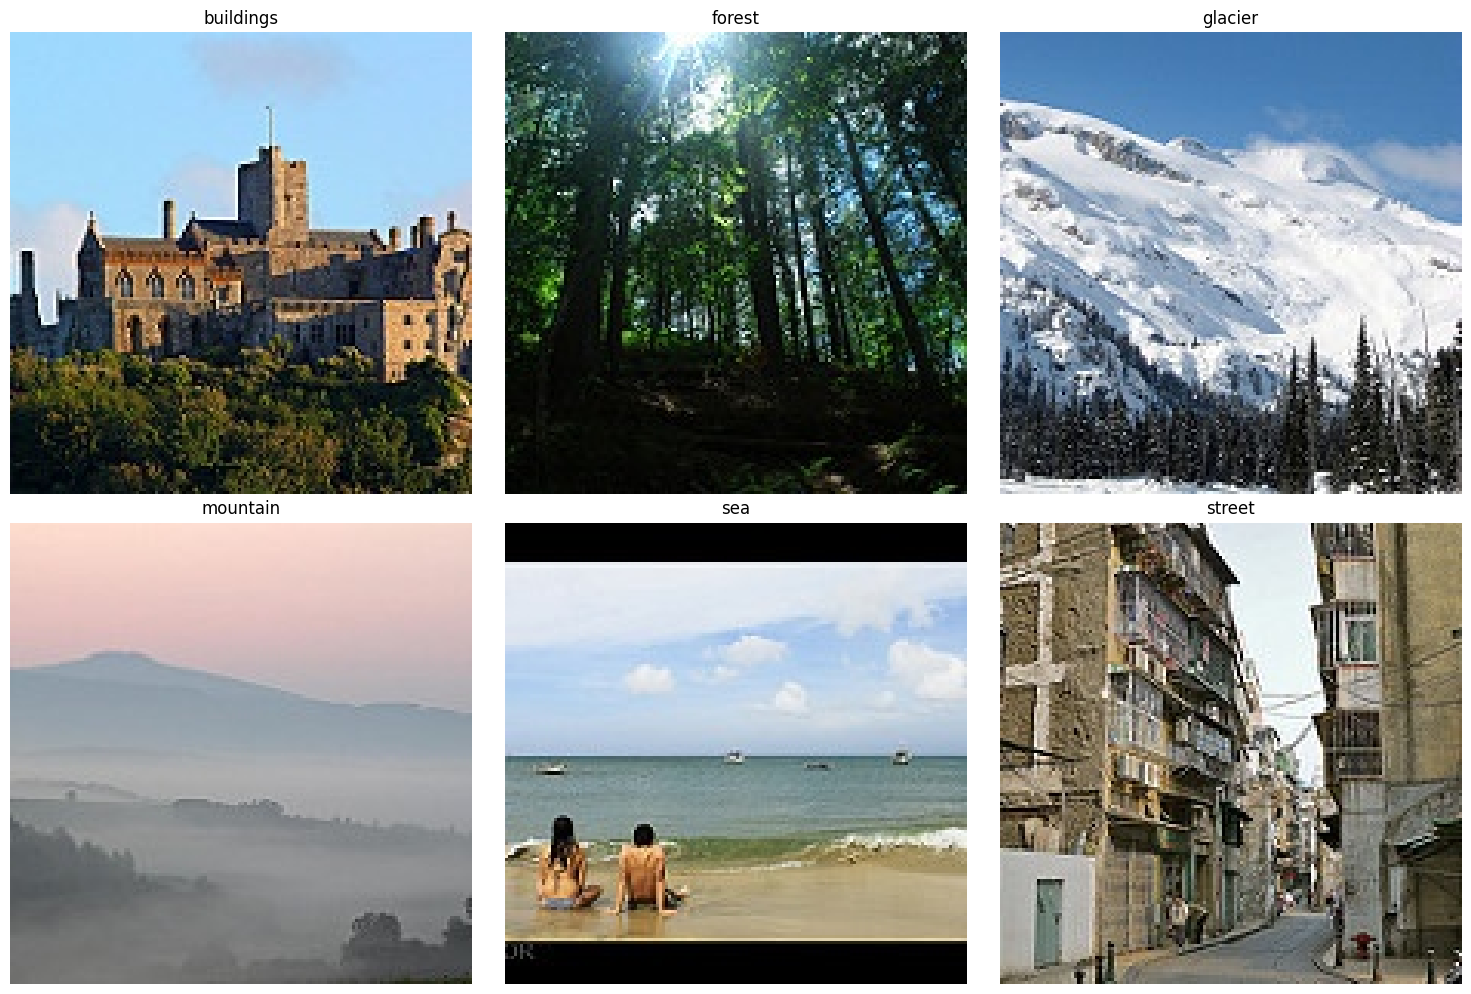

In [ ]:
class_names = sorted(train_counts.keys())

plt.figure(figsize=(15,10))

for i, class_name in enumerate(class_names):
    class_path = train_dir / class_name
    img_path = random.choice(list(class_path.glob("*.jpg")))
    img = plt.imread(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

This represents how the classes actually looks like

##  Design, Train, and Evaluate a Baseline Model

### Checking for corrupted/bad files in both train and test

In [ ]:
from PIL import Image
import os

def find_invalid_images(directory):
    bad_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.load()
            except Exception as e:
                bad_files.append((file_path, str(e)))

    return bad_files

In [ ]:
bad_train = find_invalid_images(train_dir)
bad_test = find_invalid_images(test_dir)

print("Invalid images in TRAIN:", len(bad_train))
for f, err in bad_train[:20]:
    print(f, " --> ", err)

print("\nInvalid images in TEST:", len(bad_test))
for f, err in bad_test[:20]:
    print(f, " --> ", err)

Invalid images in TRAIN: 42
/content/drive/MyDrive/Scene Classification/train/glacier/6195.jpg  -->  cannot identify image file '/content/drive/MyDrive/Scene Classification/train/glacier/6195.jpg'
/content/drive/MyDrive/Scene Classification/train/glacier/1520.jpg  -->  cannot identify image file '/content/drive/MyDrive/Scene Classification/train/glacier/1520.jpg'
/content/drive/MyDrive/Scene Classification/train/glacier/12410.jpg  -->  cannot identify image file '/content/drive/MyDrive/Scene Classification/train/glacier/12410.jpg'
/content/drive/MyDrive/Scene Classification/train/glacier/8283.jpg  -->  cannot identify image file '/content/drive/MyDrive/Scene Classification/train/glacier/8283.jpg'
/content/drive/MyDrive/Scene Classification/train/glacier/4128.jpg  -->  cannot identify image file '/content/drive/MyDrive/Scene Classification/train/glacier/4128.jpg'
/content/drive/MyDrive/Scene Classification/train/glacier/8218.jpg  -->  cannot identify image file '/content/drive/MyDrive/S

### Checking for Imbalance classes in datasets

In [ ]:
import os

# Dictionary to store class counts
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        class_counts[class_name] = len(images)  # Count images in each class

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>20}")
print("=" * 45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>20}")

print("=" * 45)


Class Distribution:
Class Name                  Valid Image Count
buildings                                2191
forest                                   2271
glacier                                  2404
mountain                                 2512
sea                                      2274
street                                   2382


## Model Training:

### Create train, validation and test datasets

We have train and test folder so now we will split training folder into 80% train and 20% vaalidation.

In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

all_train_image_paths = []
all_train_labels = []
class_name_to_label = {name: i for i, name in enumerate(class_names)}

bad_train_paths_set = {f for f, err in bad_train}

for class_name in class_names:
    class_path = train_dir / class_name
    for img_path in class_path.glob("*.jpg"):
        if str(img_path) not in bad_train_paths_set:
            all_train_image_paths.append(str(img_path))
            all_train_labels.append(class_name_to_label[class_name])

all_train_image_paths = np.array(all_train_image_paths)
all_train_labels = np.array(all_train_labels)

np.random.seed(SEED)
indices = np.arange(len(all_train_image_paths))
np.random.shuffle(indices)

shuffled_image_paths = all_train_image_paths[indices]
shuffled_labels = all_train_labels[indices]

validation_split_ratio = 0.2
train_size = int((1 - validation_split_ratio) * len(shuffled_image_paths))

train_paths = shuffled_image_paths[:train_size]
train_labels = shuffled_labels[:train_size]

val_paths = shuffled_image_paths[train_size:]
val_labels = shuffled_labels[train_size:]

def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE # Ensure AUTOTUNE is defined as it was before

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

all_test_image_paths = []
all_test_labels = []
bad_test_paths_set = {f for f, err in bad_test}

for class_name in class_names:
    class_path = test_dir / class_name
    for img_path in class_path.glob("*.jpg"):
        if str(img_path) not in bad_test_paths_set:
            all_test_image_paths.append(str(img_path))
            all_test_labels.append(class_name_to_label[class_name])

test_paths = np.array(all_test_image_paths)
test_labels = np.array(all_test_labels)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Print dataset sizes to confirm
print(f"Number of training samples: {len(train_paths)}")
print(f"Number of validation samples: {len(val_paths)}")
print(f"Number of test samples: {len(test_paths)}")
print("Classes:", class_names)
print("Number of classes:", num_classes)

Number of training samples: 11193
Number of validation samples: 2799
Number of test samples: 3000
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


### Normalize image and optimize pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

Pixel values normally range from 0 to 255.
After normalization they become 0 to 1, which helps the model train more stably.

### Data augmentation

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

### Visualize augmented images

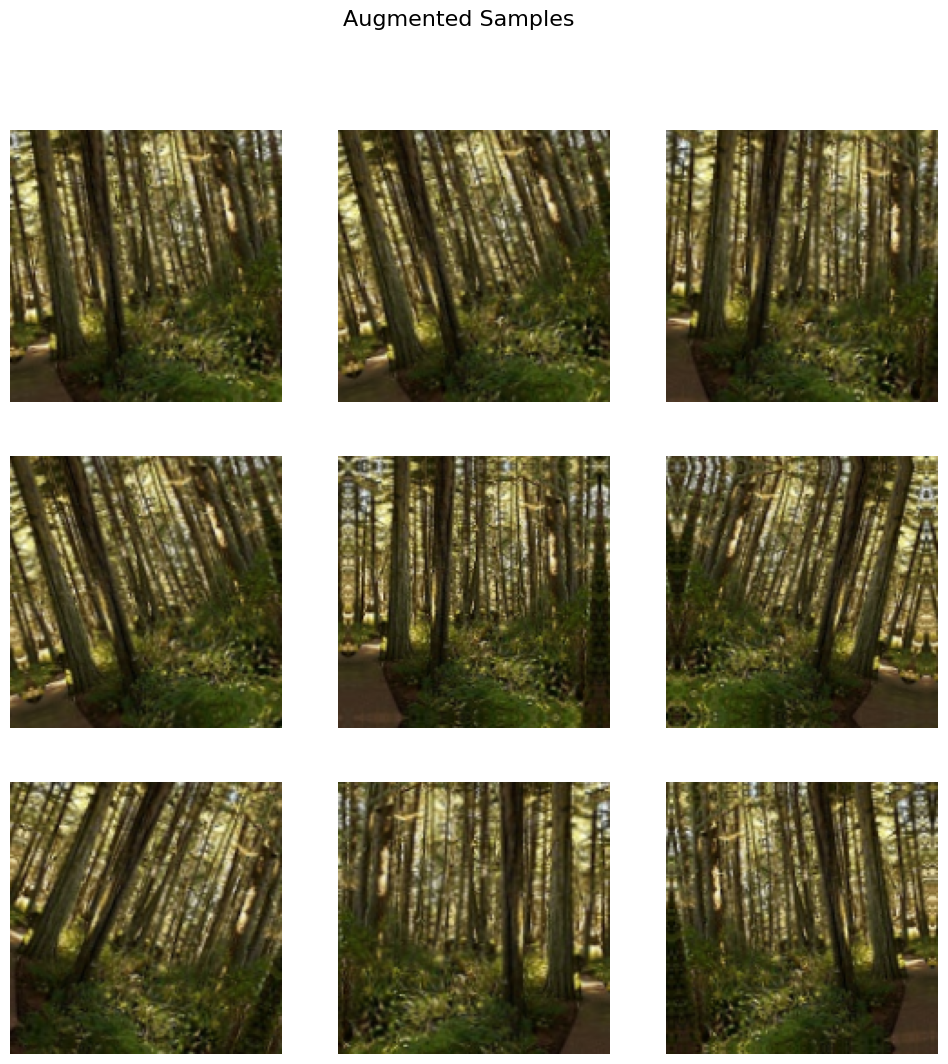

In [ ]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 12))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0])
        plt.axis("off")
    plt.suptitle("Augmented Samples", fontsize=16)
    plt.show()

This gives you direct evidence that augmentation was used.

## Experimentation and Comparative Analysis

## Baseline CNN from scratch

According to guideline

1. 3 convolution layers.
2. Each followed by pooling.
3. 3 fully connected layers.
4. output layer for classification.

In [ ]:
baseline_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,604,998 (36.64 MB)

 Trainable params: 9,604,998 (36.64 MB)

 Non-trainable params: 0 (0.00 B)

### Compile baseline model

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

1. sparse_categorical_crossentropy is suitable because the labels are integer encoded.

2. accuracy, precision, and recall are required evaluation metrics.

### Train baseline model

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, reduce_lr]
)

baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 65s 159ms/step - accuracy: 0.5579 - loss: 1.1171 - val_accuracy: 0.6545 - val_loss: 0.9340 - learning_rate: 0.0010
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6750 - loss: 0.8561 - val_accuracy: 0.7081 - val_loss: 0.7796 - learning_rate: 0.0010
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7279 - loss: 0.7300 - val_accuracy: 0.7596 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7678 - loss: 0.6448 - val_accuracy: 0.7735 - val_loss: 0.5977 - learning_rate: 0.0010
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7737 - loss: 0.6042 - val_accuracy: 0.7985 - val_loss: 0.5358 - learning_rate: 0.0010
Epoch 6/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8018 - loss: 0.5541 - val_accuracy: 0.7899 - val_loss: 0.5678 - learning_rate: 0.0010
Epoch 7/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8100 - 

This is important cause
1. EarlyStopping prevents unnecessary training and helps reduce overfitting.

2. ReduceLROnPlateau lowers learning rate when improvement slows down.

### Plotting training curves

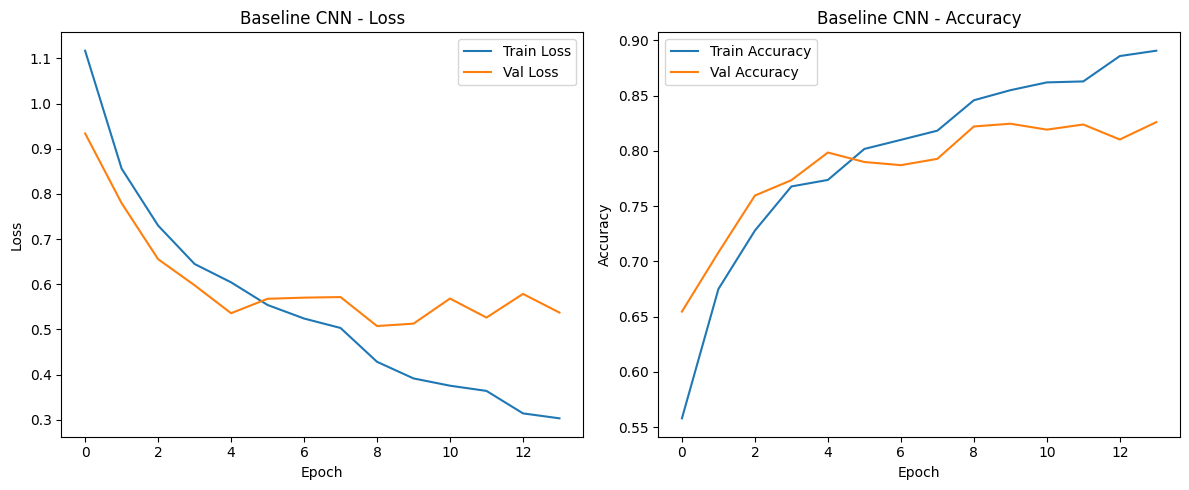

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN")

### Evaluate baseline model

In [ ]:
baseline_results = baseline_model.evaluate(test_ds, verbose=1)
print("Baseline test results:", baseline_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.8230 - loss: 0.5314
Baseline test results: [0.5314481258392334, 0.8230000138282776]


### Classification report and confusion matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

   buildings       0.74      0.84      0.79       437
      forest       0.94      0.96      0.95       474
     glacier       0.85      0.70      0.77       553
    mountain       0.73      0.82      0.77       525
         sea       0.86      0.78      0.82       510
      street       0.84      0.86      0.85       501

    accuracy                           0.82      3000
   macro avg       0.83      0.83      0.82      3000
weighted avg       0.83      0.82      0.82      3000



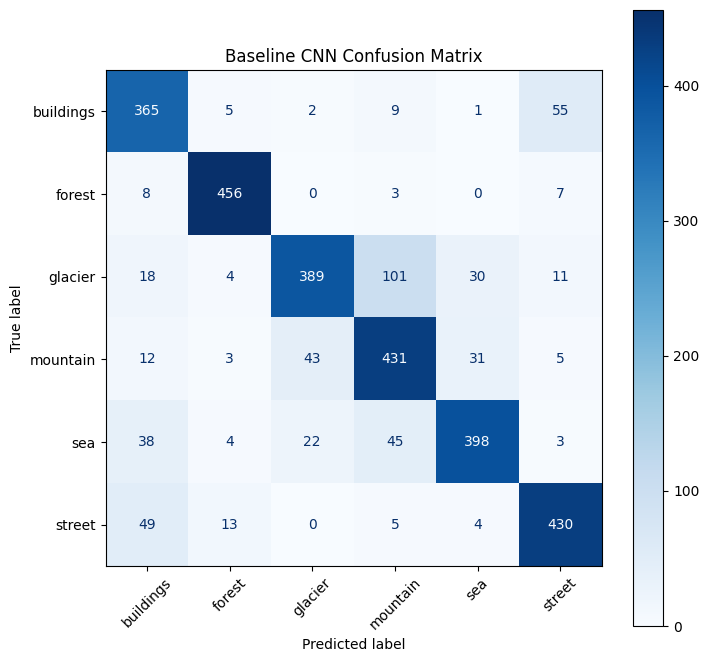

In [ ]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = baseline_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Baseline CNN Confusion Matrix")
plt.show()

It gives F1 score, confusion matrix and precision.

### Oredict on sample test image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


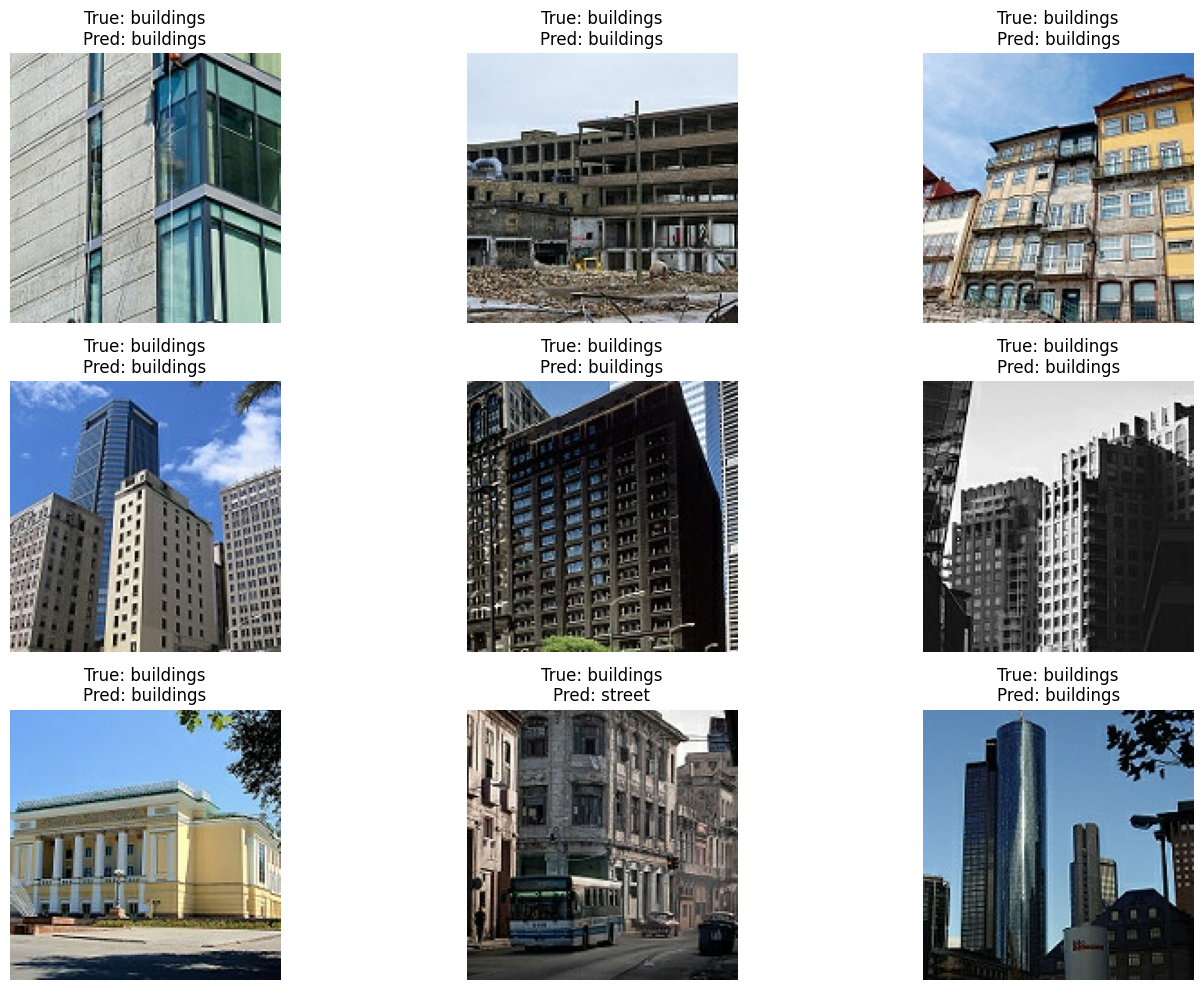

In [ ]:
for images, labels in test_ds.take(1):
    preds = baseline_model.predict(images)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(15,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## Deeper CNN with regularization

The guide wants the deeper model to have at least double the layers compared to baseline and include regularization like Batch Normalization and Dropout.

### Building deeper CNN

In [ ]:
def build_deeper_model(dropout_rate=0.5, optimizer='adam'):
    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        data_augmentation,

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

deeper_model_adam = build_deeper_model(dropout_rate=0.5, optimizer='adam')
deeper_model_adam.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 10,946,534 (41.76 MB)

 Trainable params: 10,946,086 (41.76 MB)

 Non-trainable params: 448 (1.75 KB)

This is important because This model is deeper and more powerful. And also regulariazation layers help reduce overfitting too.

### Train deeper model with Adam

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
start_time = time.time()

history_deeper_adam = deeper_model_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, reduce_lr]
)

deeper_adam_train_time = time.time() - start_time
print(f"Deeper model (Adam) training time: {deeper_adam_train_time:.2f} seconds")

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 133ms/step - accuracy: 0.2410 - loss: 2.2333 - val_accuracy: 0.1708 - val_loss: 1.7993 - learning_rate: 0.0010
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.2544 - loss: 1.7007 - val_accuracy: 0.2572 - val_loss: 1.6537 - learning_rate: 0.0010
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.2630 - loss: 1.7021 - val_accuracy: 0.2808 - val_loss: 1.6753 - learning_rate: 0.0010
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.2723 - loss: 1.6505 - val_accuracy: 0.3208 - val_loss: 1.5504 - learning_rate: 0.0010
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.2823 - loss: 1.6129 - val_accuracy: 0.2772 - val_loss: 1.6091 - learning_rate: 0.0010
Epoch 6/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step - accuracy: 0.3155 - loss: 1.5566 - val_accuracy: 0.4012 - val_loss: 1.3975 - learning_rate: 0.0010
Epoch 7/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.3

### Plotting deeper model history

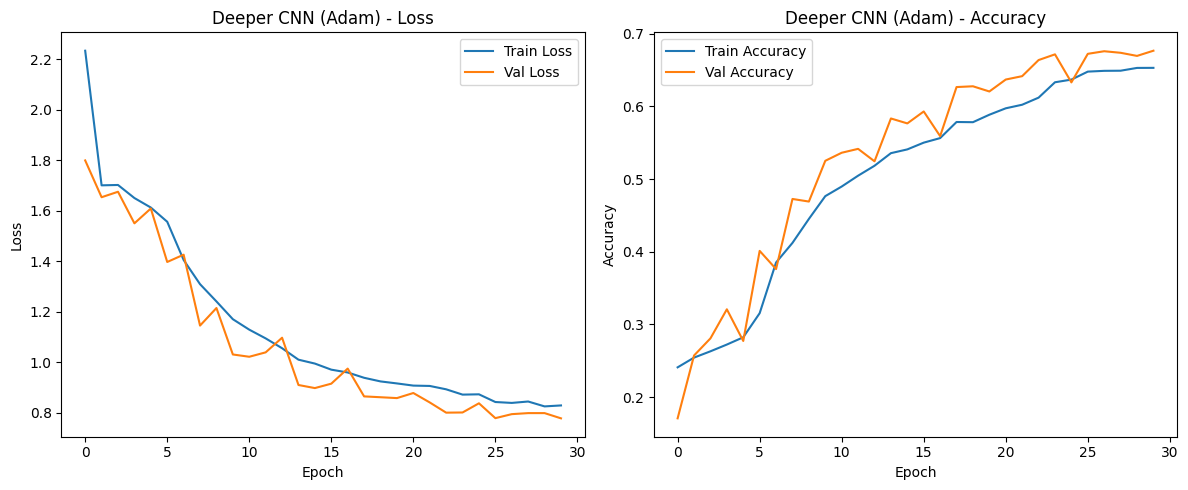

In [ ]:
plot_history(history_deeper_adam, "Deeper CNN (Adam)")

### Evaluate deeper model with Adam

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6853 - loss: 0.7690
Deeper CNN (Adam) test results: [0.7690486907958984, 0.6853333115577698]
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
              precision    recall  f1-score   support

   buildings       0.74      0.74      0.74       437
      forest       0.91      0.98      0.94       474
     glacier       0.54      0.79      0.64       553
    mountain       0.58      0.72      0.64       525
         sea       0.33      0.04      0.06       510
      street       0.80      0.87      0.83       501

    accuracy                           0.69      3000
   macro avg       0.65      0.69      0.64      3000
weighted avg       0.64      0.69      0.64      3000



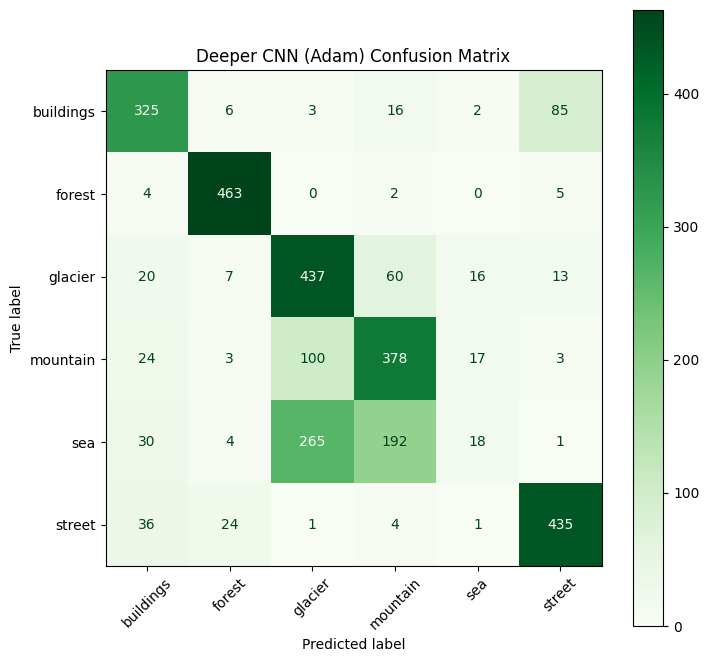

In [ ]:
deeper_adam_results = deeper_model_adam.evaluate(test_ds, verbose=1)
print("Deeper CNN (Adam) test results:", deeper_adam_results)

y_pred_probs_deeper = deeper_model_adam.predict(test_ds)
y_pred_deeper = np.argmax(y_pred_probs_deeper, axis=1)

print(classification_report(y_true, y_pred_deeper, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_deeper)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Greens', xticks_rotation=45)
plt.title("Deeper CNN (Adam) Confusion Matrix")
plt.show()

## Optimizer comparison SGD vs Adam

### Train deeper model with SGD

In [ ]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

deeper_model_sgd = build_deeper_model(dropout_rate=0.5, optimizer=sgd_optimizer)

In [ ]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

deeper_model_sgd = build_deeper_model(dropout_rate=0.5, optimizer=sgd_optimizer)

start_time = time.time()

history_deeper_sgd = deeper_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, reduce_lr]
)

deeper_sgd_train_time = time.time() - start_time
print(f"Deeper model (SGD) training time: {deeper_sgd_train_time:.2f} seconds")

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 118ms/step - accuracy: 0.2145 - loss: 2.0170 - val_accuracy: 0.1565 - val_loss: 1.8016 - learning_rate: 0.0100
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.3250 - loss: 1.5795
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
350/350 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.3555 - loss: 1.4980 - val_accuracy: 0.4116 - val_loss: 1.3273 - learning_rate: 0.0100
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.4500 - loss: 1.2862 - val_accuracy: 0.4741 - val_loss: 1.1817 - learning_rate: 0.0050
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4760 - loss: 1.2392
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.4832 - loss: 1.2327 - val_accuracy: 0.5323 - val_loss: 1.1612 - learning_rate: 0.0050
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.5091 -

### Evaluate SGD model

In [ ]:
deeper_sgd_results = deeper_model_sgd.evaluate(test_ds, verbose=1)
print("Deeper CNN (SGD) test results:", deeper_sgd_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1583 - loss: 1.8036
Deeper CNN (SGD) test results: [1.8036353588104248, 0.15833333134651184]


## Ablation study

The guide asks you to remove one component such as dropout and analyze change in performance.

### Train model without dropout

In [ ]:
ablation_model = build_deeper_model(dropout_rate=0.0, optimizer='adam')


In [ ]:
ablation_model = build_deeper_model(dropout_rate=0.0, optimizer='adam')

start_time = time.time()

history_ablation = ablation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, reduce_lr]
)

ablation_train_time = time.time() - start_time
print(f"Ablation model training time: {ablation_train_time:.2f} seconds")

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 47s 124ms/step - accuracy: 0.4890 - loss: 1.7420 - val_accuracy: 0.3712 - val_loss: 1.7639 - learning_rate: 0.0010
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6181 - loss: 0.9765
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.6373 - loss: 0.9385 - val_accuracy: 0.6767 - val_loss: 0.8367 - learning_rate: 0.0010
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step - accuracy: 0.7160 - loss: 0.7544 - val_accuracy: 0.7492 - val_loss: 0.6798 - learning_rate: 5.0000e-04
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.7464 - loss: 0.6769 - val_accuracy: 0.7481 - val_loss: 0.6615 - learning_rate: 5.0000e-04
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.7665 - loss: 0.6287 - val_accuracy: 0.7292 - val_loss: 0.7562 - learning_rate: 5.0000e-04
Epoch 6/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accu

### Evaluate ablation model

In [ ]:
ablation_results = ablation_model.evaluate(test_ds, verbose=1)
print("Ablation model test results:", ablation_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7987 - loss: 0.5960
Ablation model test results: [0.5959599018096924, 0.7986666560173035]


#  Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).

##  Loading and Adapting a Pre- Trained Model

Using Pre-trained model and comparing it to the scratch models.

For our dataset, MobileNetV2 is a very good choice because:

1. it is lighter and faster than ResNet/VGG.

2. it works very well for natural scene images.

3. it is easy to fine-tune in Colab.

### Reload datasets for MobileNetV2 input size

In [ ]:
IMG_SIZE_TL = (224, 224)

all_train_image_paths_tl = []
all_train_labels_tl = []
class_name_to_label_tl = {name: i for i, name in enumerate(class_names)}

bad_train_paths_set_tl = {f for f, err in bad_train}

for class_name in class_names:
    class_path = train_dir / class_name
    for img_path in class_path.glob("*.jpg"):
        if str(img_path) not in bad_train_paths_set_tl:
            all_train_image_paths_tl.append(str(img_path))
            all_train_labels_tl.append(class_name_to_label_tl[class_name])

all_train_image_paths_tl = np.array(all_train_image_paths_tl)
all_train_labels_tl = np.array(all_train_labels_tl)

np.random.seed(SEED)
indices_tl = np.arange(len(all_train_image_paths_tl))
np.random.shuffle(indices_tl)

shuffled_image_paths_tl = all_train_image_paths_tl[indices_tl]
shuffled_labels_tl = all_train_labels_tl[indices_tl]

validation_split_ratio = 0.2
train_size_tl = int((1 - validation_split_ratio) * len(shuffled_image_paths_tl))

train_paths_tl = shuffled_image_paths_tl[:train_size_tl]
train_labels_tl = shuffled_labels_tl[:train_size_tl]

val_paths_tl = shuffled_image_paths_tl[train_size_tl:]
val_labels_tl = shuffled_labels_tl[train_size_tl:]

all_test_image_paths_tl = []
all_test_labels_tl = []
bad_test_paths_set_tl = {f for f, err in bad_test} # Filter bad test images if any

for class_name in class_names:
    class_path = test_dir / class_name
    for img_path in class_path.glob("*.jpg"):
        if str(img_path) not in bad_test_paths_set_tl:
            all_test_image_paths_tl.append(str(img_path))
            all_test_labels_tl.append(class_name_to_label_tl[class_name])

test_paths_tl = np.array(all_test_image_paths_tl)
test_labels_tl = np.array(all_test_labels_tl)

# --- Preprocessing function for Transfer Learning (MobileNetV2) ---
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def load_and_preprocess_image_tl(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE_TL)
    img = preprocess_input(img) # MobileNetV2 specific preprocessing
    return img, label

# --- Create tf.data.Dataset for train, validation, and test ---
AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = tf.data.Dataset.from_tensor_slices((train_paths_tl, train_labels_tl))
train_ds_tl = train_ds_tl.map(load_and_preprocess_image_tl, num_parallel_calls=AUTOTUNE)
train_ds_tl = train_ds_tl.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds_tl = tf.data.Dataset.from_tensor_slices((val_paths_tl, val_labels_tl))
val_ds_tl = val_ds_tl.map(load_and_preprocess_image_tl, num_parallel_calls=AUTOTUNE)
val_ds_tl = val_ds_tl.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds_tl = tf.data.Dataset.from_tensor_slices((test_paths_tl, test_labels_tl))
test_ds_tl = test_ds_tl.map(load_and_preprocess_image_tl, num_parallel_calls=AUTOTUNE)
test_ds_tl = test_ds_tl.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Print dataset sizes to confirm
print(f"Number of training samples (TL): {len(train_paths_tl)}")
print(f"Number of validation samples (TL): {len(val_paths_tl)}")
print(f"Number of test samples (TL): {len(test_paths_tl)}")
print("Classes:", class_names)
print("Number of classes:", num_classes)

Number of training samples (TL): 11193
Number of validation samples (TL): 2799
Number of test samples (TL): 3000
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


### Preprocess for MobileNetV2

The preprocessing for MobileNetV2 is now integrated into the dataset creation in the previous cell.

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

### Build transfer learning model

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

transfer_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

This is important because this is feature extraction:

1. the convolution base is frozen.
2. only the new classifier layers are trained.

### Train transfer learning model

In [ ]:
start_time = time.time()

history_transfer = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

transfer_train_time = time.time() - start_time
print(f"Transfer learning training time: {transfer_train_time:.2f} seconds")

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 141s 298ms/step - accuracy: 0.8750 - loss: 0.3463 - val_accuracy: 0.9028 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 170ms/step - accuracy: 0.9083 - loss: 0.2424 - val_accuracy: 0.9121 - val_loss: 0.2525 - learning_rate: 0.0010
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 83s 174ms/step - accuracy: 0.9158 - loss: 0.2148 - val_accuracy: 0.9218 - val_loss: 0.2418 - learning_rate: 0.0010
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 62s 176ms/step - accuracy: 0.9244 - loss: 0.1953 - val_accuracy: 0.9218 - val_loss: 0.2350 - learning_rate: 0.0010
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.9304 - loss: 0.1785 - val_accuracy: 0.9175 - val_loss: 0.2458 - learning_rate: 0.0010
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9360 - loss: 0.1623
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
350/350 ━━━━━━━━━━━━━━━━━━━━ 67s 192ms/step - accuracy: 0.93

### Fine tune the pre-trained model

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_finetune = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

finetune_train_time = time.time() - start_time
print(f"Fine-tuning training time: {finetune_train_time:.2f} seconds")

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 370s 922ms/step - accuracy: 0.8522 - loss: 0.4869 - val_accuracy: 0.9225 - val_loss: 0.2740 - learning_rate: 1.0000e-05
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.8970 - loss: 0.2839
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
350/350 ━━━━━━━━━━━━━━━━━━━━ 240s 675ms/step - accuracy: 0.9021 - loss: 0.2696 - val_accuracy: 0.9210 - val_loss: 0.2784 - learning_rate: 1.0000e-05
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 189s 536ms/step - accuracy: 0.9228 - loss: 0.2069 - val_accuracy: 0.9200 - val_loss: 0.2738 - learning_rate: 5.0000e-06
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9282 - loss: 0.1911
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
350/350 ━━━━━━━━━━━━━━━━━━━━ 164s 463ms/step - accuracy: 0.9300 - loss: 0.1835 - val_accuracy: 0.9196 - val_loss: 0.2707 - learning_rate: 5.0000e-06
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 217s 616ms/ste

This is important because this ia actual fine-tuning"

1. First train new top layers
2. then unfreeze part of the base model.
3. use a very small learning rate to avoid damaging pretrained features

In [ ]:
from sklearn.metrics import classification_report

y_true_tl = np.concatenate([y for x, y in test_ds_tl], axis=0)
y_pred_probs_tl = transfer_model.predict(test_ds_tl)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

94/94 ━━━━━━━━━━━━━━━━━━━━ 930s 294ms/step
              precision    recall  f1-score   support

   buildings       0.96      0.89      0.93       437
      forest       0.98      1.00      0.99       474
     glacier       0.83      0.89      0.86       553
    mountain       0.91      0.80      0.85       525
         sea       0.94      0.98      0.96       510
      street       0.91      0.97      0.94       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



### Evaluate transfer learning model

In [ ]:
transfer_results = transfer_model.evaluate(test_ds_tl, verbose=1)
print("Transfer learning / fine-tuned model test results:", transfer_results)

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.9190 - loss: 0.2523
Transfer learning / fine-tuned model test results: [0.25228315591812134, 0.9190000295639038]


## Model Evaluation and Prediction

In [ ]:
results_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deeper CNN (Adam)",
        "Deeper CNN (SGD)",
        "Ablation (No Dropout)",
        "Transfer Learning"
    ],
    "Test Loss": [
        baseline_results[0],
        deeper_adam_results[0],
        deeper_sgd_results[0],
        ablation_results[0],
        transfer_results[0]
    ],
    "Test Accuracy": [
        baseline_results[1],
        deeper_adam_results[1],
        deeper_sgd_results[1],
        ablation_results[1],
        transfer_results[1]
    ],
    "Training Time (sec)": [
        baseline_train_time,
        deeper_adam_train_time,
        deeper_sgd_train_time,
        ablation_train_time,
        transfer_train_time + finetune_train_time
    ]
})

results_df = results_df.round(4)
results_df

### Plot comparison

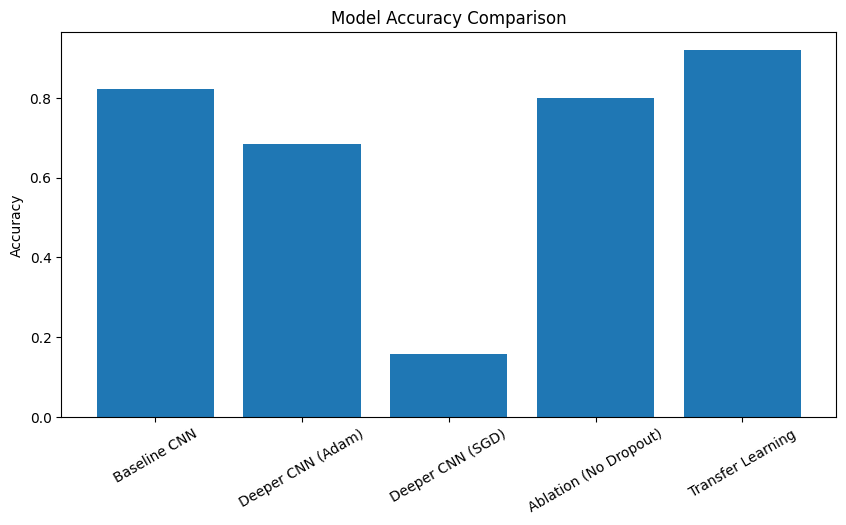

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

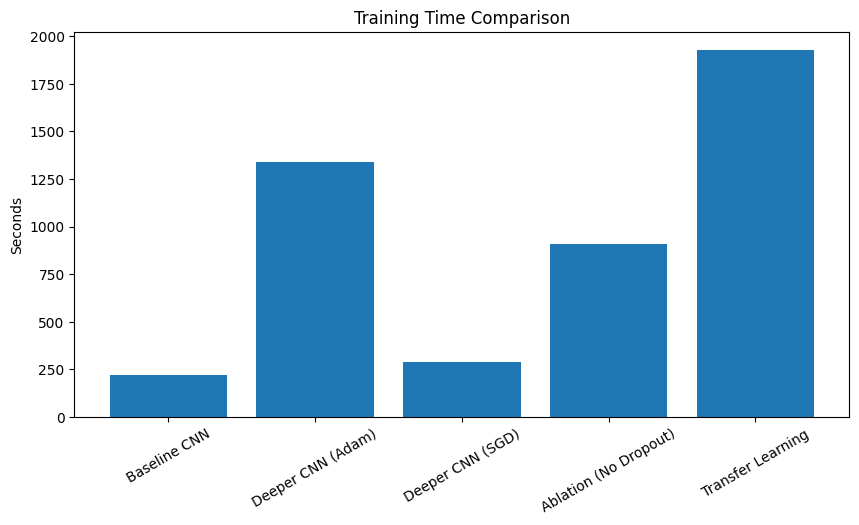

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Training Time (sec)"])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=30)
plt.show()